In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
df = pd.read_csv("customer_segmentation.csv")

# Display first 5 rows
print(df.head())

   CustomerID  Age  AnnualIncome  SpendingScore
0           1   19            15             39
1           2   21            15             81
2           3   20            16              6
3           4   23            16             77
4           5   31            17             40


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     20 non-null     int64
 1   Age            20 non-null     int64
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
dtypes: int64(4)
memory usage: 768.0 bytes
None


In [4]:
print(df.describe())


       CustomerID        Age  AnnualIncome  SpendingScore
count    20.00000  20.000000     20.000000      20.000000
mean     10.50000  33.650000     19.500000      50.800000
std       5.91608  15.114563      2.946898      33.942056
min       1.00000  19.000000     15.000000       3.000000
25%       5.75000  22.000000     17.000000      14.750000
50%      10.50000  30.500000     19.500000      53.000000
75%      15.25000  35.500000     22.000000      77.500000
max      20.00000  67.000000     24.000000      99.000000


In [5]:
print(df.isnull().sum())

CustomerID       0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


In [14]:
df = df.drop_duplicates()

In [15]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [6]:
X = df[['AnnualIncome', 'SpendingScore']]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
# Number of customers in each cluster

print(df['Cluster'].value_counts())

# Average values of each cluster

print(
    df.groupby('Cluster')[
        ['AnnualIncome','SpendingScore']
    ].mean()
)

Cluster
0    5
4    4
1    4
2    4
3    3
Name: count, dtype: int64
         AnnualIncome  SpendingScore
Cluster                             
0               16.00      62.600000
1               22.50      23.250000
2               22.50      79.000000
3               19.00      88.333333
4               18.25       7.250000


In [8]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

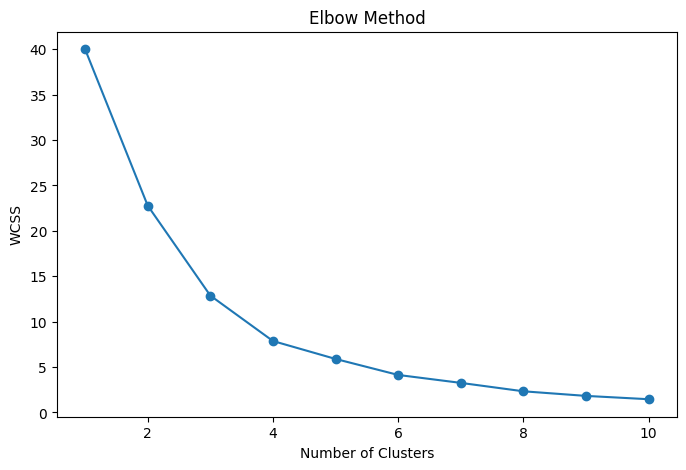

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [12]:
print(df.head(10))

   CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0           1   19            15             39        0
1           2   21            15             81        0
2           3   20            16              6        4
3           4   23            16             77        0
4           5   31            17             40        0
5           6   22            17             76        0
6           7   35            18              6        4
7           8   23            18             94        3
8           9   64            19              3        4
9          10   30            19             72        3


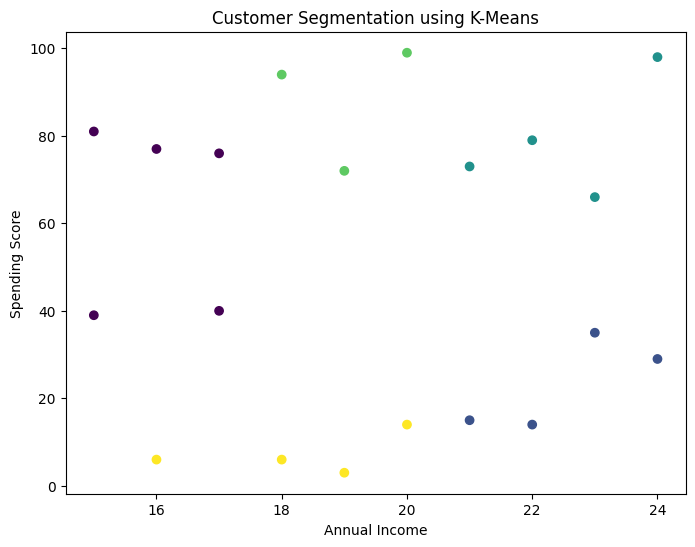

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation using K-Means")

plt.show()

Business Insights
After applying K-Means clustering, the customers are divided into different 
groups based on their Annual Income and Spending Score. The company can use these groups 
to design targeted marketing strategies and improve customer satisfaction.
1.Low Income – Low Spending Customers
2.Low Income – High Spending Customers
3.High Income – Low Spending Customers
4.High Income – High Spending Customers
5.Moderate Income – Moderate Spending Customers
Identify high-value customers and provide premium services.
Increase sales by offering personalized recommendations.